Loaded arrays:
HSR raw shape: (2, 1980)
ecDNA raw shape: (2, 1980)
1D profile length: 1980
First 10 HSR values: [ 398.68613434  819.26673889  410.94779205   97.07594872  149.24460983
  525.09807587  979.40310669 1386.64303589  431.31414032  704.64390564]
First 10 ecDNA values: [ 5991.89782715  4049.2635498   1873.00967407   452.14998627
   903.10195923  1506.5479126  12190.03320312  6189.1574707
  1431.15789795  1987.67858887]

Top candidate integration windows:
center_bin	window_start	window_end	pval	qval	-log10(p)	window_log2FC	HSR_mean	BG_mean	combined_score
1619	1617	1621	1.334e-06	6.605e-04	5.875	2.913	35891.754	6641.361	17.111
827	825	829	1.601e-05	1.865e-03	4.796	3.350	15263107.355	33307.290	16.066
1048	1046	1050	8.006e-05	4.404e-03	4.097	2.703	65326.645	12070.751	11.074
1620	1618	1622	5.604e-05	3.963e-03	4.251	2.285	25605.093	8240.919	9.715
825	823	827	1.501e-03	2.378e-02	2.824	2.716	8526949.645	966212.299	7.669
1621	1619	1623	5.444e-04	1.412e-02	3.264	2.147	23306.621	8700.990	

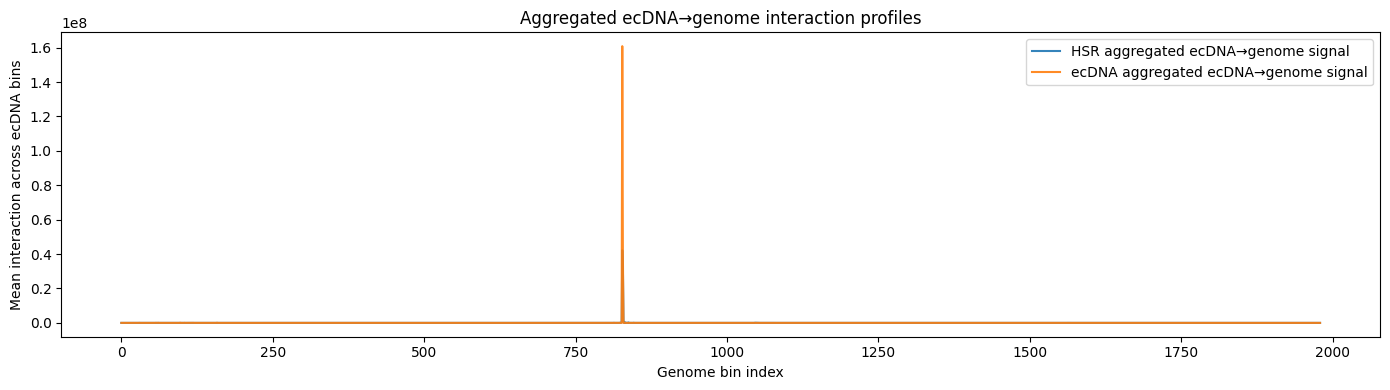

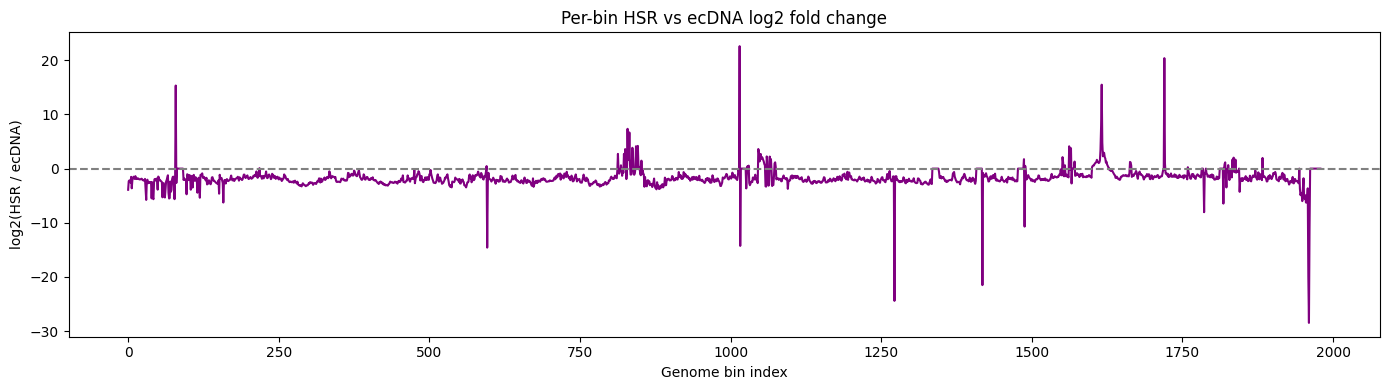

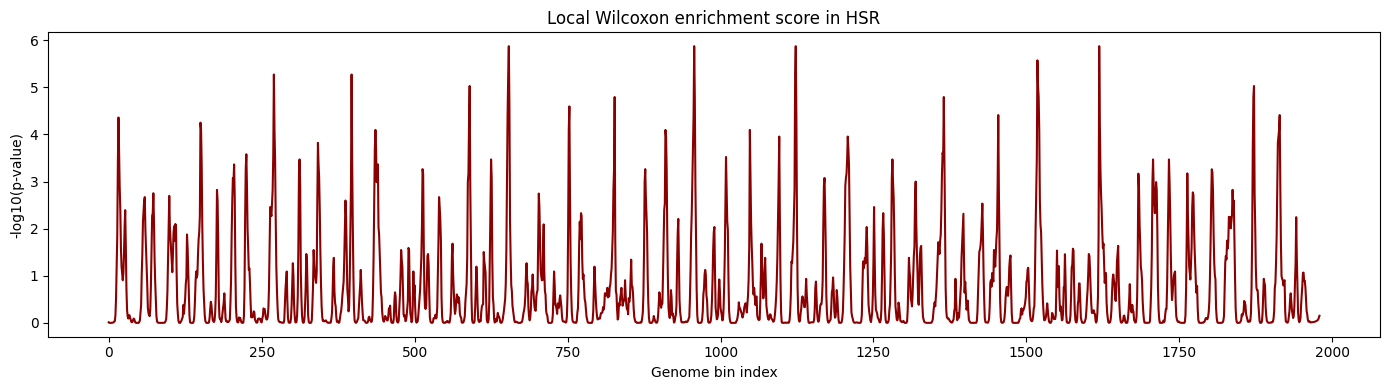

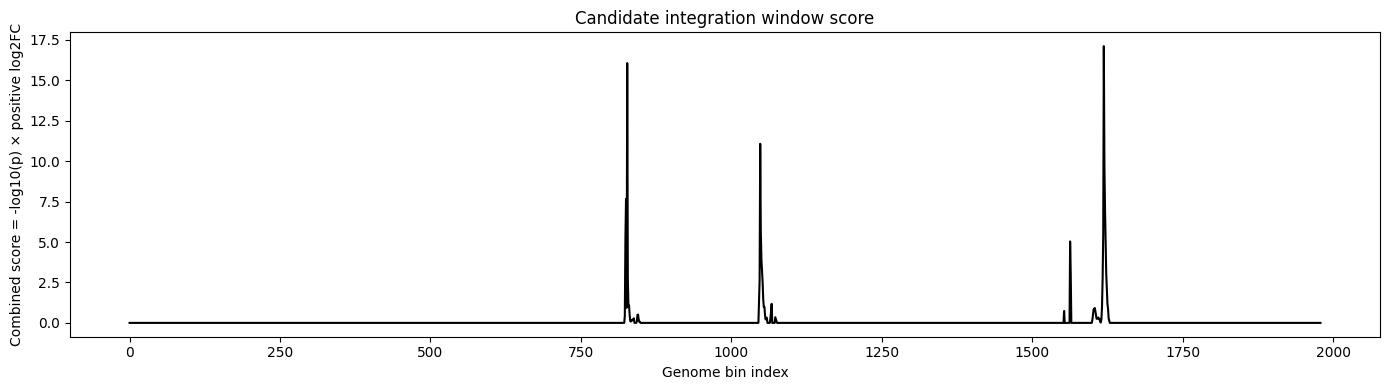

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

BASE_DIR = r"C:\Users\ronit\Downloads\CSE_280A_Project"
RESULTS_DIR = os.path.join(BASE_DIR, "results")
FILE1 = os.path.join(RESULTS_DIR, "comparison_ec_vs_genome_1.npy")  # assumed HSR
FILE2 = os.path.join(RESULTS_DIR, "comparison_ec_vs_genome_2.npy")  # assumed ecDNA

# -----------------------------
# Parameters
# -----------------------------
EPS = 1e-8
WINDOW_RADIUS = 2          # signal window size = 2*WINDOW_RADIUS + 1 bins
BACKGROUND_RADIUS = 20     # compare against local background within +/- 20 bins
USE_MEDIAN = True          # use median log2FC across window; more robust than mean
TOP_K = 20                 # number of top windows to print / plot

# -----------------------------
# Helpers
# -----------------------------
def to_1d_profile(arr: np.ndarray) -> np.ndarray:
    """
    Convert input array into a 1D genome interaction profile.
    If arr is 2D: assume shape = (n_ecDNA_bins, n_genome_bins), average over ecDNA bins.
    If arr is 1D: return as-is.
    """
    arr = np.asarray(arr, dtype=float)

    if arr.ndim == 1:
        return arr
    elif arr.ndim == 2:
        # average interaction across ecDNA bins for each genome bin
        return np.mean(arr, axis=0)
    else:
        raise ValueError(f"Expected 1D or 2D array, got shape {arr.shape}")


def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    """
    Benjamini-Hochberg FDR correction.
    """
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    qvals = np.empty(n, dtype=float)

    prev = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        q = ranked[i] * n / rank
        prev = min(prev, q)
        qvals[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.clip(qvals, 0, 1)
    return out


def extract_signal_and_background(profile: np.ndarray, center: int,
                                  window_radius: int,
                                  background_radius: int):
    """
    For a center bin, return:
      signal window values
      background window values (excluding signal window)
    """
    n = len(profile)
    left = max(0, center - background_radius)
    right = min(n, center + background_radius + 1)

    sig_left = max(0, center - window_radius)
    sig_right = min(n, center + window_radius + 1)

    signal = profile[sig_left:sig_right]

    bg_left = profile[left:sig_left]
    bg_right = profile[sig_right:right]
    background = np.concatenate([bg_left, bg_right])

    return signal, background, sig_left, sig_right


def score_windows(hsr_profile: np.ndarray,
                  ec_profile: np.ndarray,
                  window_radius: int,
                  background_radius: int):
    """
    For each genome bin:
      - compare HSR local signal window vs HSR local background using one-sided Mann-Whitney U
      - compute per-bin log2FC = log2((HSR+eps)/(EC+eps))
      - summarize window log2FC by median or mean
    """
    n = len(hsr_profile)
    results = []

    per_bin_log2fc = np.log2((hsr_profile + EPS) / (ec_profile + EPS))

    for center in range(n):
        signal, background, sig_left, sig_right = extract_signal_and_background(
            hsr_profile, center, window_radius, background_radius
        )

        # skip bins too close to the edge or with insufficient background
        if len(signal) < 2 or len(background) < 5:
            results.append((center, np.nan, np.nan, np.nan, np.nan, sig_left, sig_right))
            continue

        # One-sided test: is signal > background?
        try:
            stat, pval = mannwhitneyu(signal, background, alternative="greater")
        except ValueError:
            pval = np.nan
            stat = np.nan

        window_log2fc_vals = per_bin_log2fc[sig_left:sig_right]
        if USE_MEDIAN:
            window_log2fc = np.median(window_log2fc_vals)
        else:
            window_log2fc = np.mean(window_log2fc_vals)

        signal_mean = np.mean(signal)
        background_mean = np.mean(background)

        results.append((center, pval, window_log2fc, signal_mean, background_mean, sig_left, sig_right))

    return results, per_bin_log2fc


# -----------------------------
# Load data
# -----------------------------
hsr_arr = np.load(FILE1)
ec_arr = np.load(FILE2)

print("Loaded arrays:")
print("HSR raw shape:", hsr_arr.shape)
print("ecDNA raw shape:", ec_arr.shape)

hsr_profile = to_1d_profile(hsr_arr)
ec_profile = to_1d_profile(ec_arr)

if len(hsr_profile) != len(ec_profile):
    raise ValueError(
        f"Profiles must have same length. Got HSR={len(hsr_profile)}, ecDNA={len(ec_profile)}"
    )

print("1D profile length:", len(hsr_profile))
print("First 10 HSR values:", hsr_profile[:10])
print("First 10 ecDNA values:", ec_profile[:10])

# -----------------------------
# Score windows
# -----------------------------
results, per_bin_log2fc = score_windows(
    hsr_profile,
    ec_profile,
    WINDOW_RADIUS,
    BACKGROUND_RADIUS
)

# unpack
centers = np.array([r[0] for r in results], dtype=int)
pvals = np.array([r[1] for r in results], dtype=float)
window_log2fc = np.array([r[2] for r in results], dtype=float)
signal_means = np.array([r[3] for r in results], dtype=float)
background_means = np.array([r[4] for r in results], dtype=float)
sig_lefts = np.array([r[5] for r in results], dtype=int)
sig_rights = np.array([r[6] for r in results], dtype=int)

valid = ~np.isnan(pvals)
qvals = np.full_like(pvals, np.nan)
qvals[valid] = bh_fdr(pvals[valid])

neglog10p = -np.log10(np.clip(pvals, 1e-300, 1.0))
neglog10q = -np.log10(np.clip(qvals, 1e-300, 1.0))

# Combined ranking score
# strong if locally enriched in HSR and larger in HSR than ecDNA
combined_score = neglog10p * np.maximum(window_log2fc, 0)

# -----------------------------
# Rank top windows
# -----------------------------
rank_mask = valid & np.isfinite(window_log2fc)
rank_idx = np.argsort(combined_score[rank_mask])[::-1]
ranked_centers = centers[rank_mask][rank_idx]

print("\nTop candidate integration windows:")
print("center_bin\twindow_start\twindow_end\tpval\tqval\t-log10(p)\twindow_log2FC\tHSR_mean\tBG_mean\tcombined_score")
for c in ranked_centers[:TOP_K]:
    i = c
    print(
        f"{centers[i]}\t"
        f"{sig_lefts[i]}\t"
        f"{sig_rights[i]-1}\t"
        f"{pvals[i]:.3e}\t"
        f"{qvals[i]:.3e}\t"
        f"{neglog10p[i]:.3f}\t"
        f"{window_log2fc[i]:.3f}\t"
        f"{signal_means[i]:.3f}\t"
        f"{background_means[i]:.3f}\t"
        f"{combined_score[i]:.3f}"
    )

# -----------------------------
# Save results
# -----------------------------
out_path = os.path.join(RESULTS_DIR, "window_scan_results.tsv")
with open(out_path, "w") as f:
    f.write(
        "center_bin\twindow_start\twindow_end\tpval\tqval\tneglog10p\twindow_log2fc\t"
        "hsr_signal_mean\tbackground_mean\tcombined_score\n"
    )
    for i in range(len(centers)):
        f.write(
            f"{centers[i]}\t{sig_lefts[i]}\t{sig_rights[i]-1}\t"
            f"{pvals[i]}\t{qvals[i]}\t{neglog10p[i]}\t{window_log2fc[i]}\t"
            f"{signal_means[i]}\t{background_means[i]}\t{combined_score[i]}\n"
        )

print(f"\nSaved results to: {out_path}")

# -----------------------------
# Plots
# -----------------------------
x = np.arange(len(hsr_profile))

plt.figure(figsize=(14, 4))
plt.plot(x, hsr_profile, label="HSR aggregated ecDNA→genome signal", alpha=0.9)
plt.plot(x, ec_profile, label="ecDNA aggregated ecDNA→genome signal", alpha=0.9)
plt.xlabel("Genome bin index")
plt.ylabel("Mean interaction across ecDNA bins")
plt.title("Aggregated ecDNA→genome interaction profiles")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(x, per_bin_log2fc, color="purple")
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Genome bin index")
plt.ylabel("log2(HSR / ecDNA)")
plt.title("Per-bin HSR vs ecDNA log2 fold change")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(x, neglog10p, color="darkred")
plt.xlabel("Genome bin index")
plt.ylabel("-log10(p-value)")
plt.title("Local Wilcoxon enrichment score in HSR")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(x, combined_score, color="black")
plt.xlabel("Genome bin index")
plt.ylabel("Combined score = -log10(p) × positive log2FC")
plt.title("Candidate integration window score")
plt.tight_layout()
plt.show()